In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy

c:\Users\tooba\anaconda3\envs\chatbot\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:


# Step 1: Load dataset into dataframe
data_path = r"Dataset_Plane"
classes = os.listdir(data_path)

data = []
for cls in classes:
    cls_path = os.path.join(data_path, cls)
    if os.path.isdir(cls_path):
        for img in os.listdir(cls_path):
            data.append([os.path.join(cls_path, img), cls])

df = pd.DataFrame(data, columns=["filepath", "label"])

In [3]:
df["label"].value_counts()

label
AC_PLANE     1386
NO_PLANE     1318
FL_PLANE     1281
BPD_PLANE    1280
Name: count, dtype: int64

In [ ]:


# Step 2: Split into train/val/test

train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    stratify=df["label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)


In [ ]:

# Step 3: ImageDataGenerator with normalization + augmentation

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.9,1.1],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)



In [ ]:

train_gen = train_datagen.flow_from_dataframe(

    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_dataframe(

    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = test_datagen.flow_from_dataframe(

    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)



Found 3790 validated image filenames belonging to 4 classes.
Found 948 validated image filenames belonging to 4 classes.
Found 527 validated image filenames belonging to 4 classes.


In [ ]:


# Step 4: Compute class weights (to handle imbalance)

class_weights = compute_class_weight(

    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights_dict = dict(
    zip(np.unique(train_df["label"]), class_weights)
)


In [ ]:

# Step 5: Build ResNet50 model
base_model = EfficientNetB2(

    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation="relu")(x)

x = Dropout(0.5)(x)

preds = Dense(len(classes), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=preds)

# Phase 1: Freeze base model

for layer in base_model.layers:

    layer.trainable = False

# Compile Model


model.compile(

    optimizer=Adam(learning_rate=1e-4),

    loss=CategoricalCrossentropy(label_smoothing=0.1),

    metrics=["accuracy"]
)






# Callbacks

checkpoint = ModelCheckpoint(

    "best_efficientnet_ultrasound.h5",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max"
)


earlystop = EarlyStopping(

    monitor="val_loss",

    patience=6,

    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    min_lr=1e-6
)

callbacks = [checkpoint, earlystop, reduce_lr]


In [ ]:


# Step 6: Train head first
history1 = model.fit(

    train_gen,

    validation_data=val_gen,

    epochs=12,

    callbacks=callbacks,

    class_weight=class_weights_dict
)



Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2741 - loss: 1.5059

90/90 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.2899 - loss: 1.4629 - val_accuracy: 0.4778 - val_loss: 1.2918 - learning_rate: 1.0000e-04
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3307 - loss: 1.3871

90/90 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.3233 - loss: 1.3783 - val_accuracy: 0.4903 - val_loss: 1.2367 - learning_rate: 1.0000e-04
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - accuracy: 0.3594 - loss: 1.3240 - val_accuracy: 0.4278 - val_loss: 1.1864 - learning_rate: 1.0000e-04
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.4056 - loss: 1.2719 - val_accuracy: 0.4264 - val_loss: 1.1591 - learning_rate: 1.0000e-04
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4023 - loss: 1.2602

90/90 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - accuracy: 0.4031 - loss: 1.2542 - val_accuracy: 0.5083 - val_loss: 1.1102 - learning_rate: 1.0000e-04
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4316 - loss: 1.2161

90/90 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - accuracy: 0.4170 - loss: 1.2233 - val_accuracy: 0.6153 - val_loss: 1.0950 - learning_rate: 1.0000e-04
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.4361 - loss: 1.2017 - val_accuracy: 0.5056 - val_loss: 1.0759 - learning_rate: 1.0000e-04
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4399 - loss: 1.1998

90/90 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.4375 - loss: 1.1965 - val_accuracy: 0.7069 - val_loss: 1.0653 - learning_rate: 1.0000e-04
Epoch 9/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.4385 - loss: 1.1802 - val_accuracy: 0.5208 - val_loss: 1.0675 - learning_rate: 1.0000e-04
Epoch 10/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.4493 - loss: 1.1649 - val_accuracy: 0.6000 - val_loss: 1.0639 - learning_rate: 1.0000e-04


In [ ]:


# Step 7: Fine-tune last ResNet blocks

for layer in base_model.layers[-80:]:

    layer.trainable = True


model.compile(

    optimizer=Adam(learning_rate=1e-5),

    loss=CategoricalCrossentropy(label_smoothing=0.1),

    metrics=["accuracy"]
)


history2 = model.fit(

    train_gen,

    validation_data=val_gen,

    epochs=25,

    callbacks=callbacks,

    class_weight=class_weights_dict
)


Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 376s 4s/step - accuracy: 0.4174 - loss: 1.8378 - val_accuracy: 0.2500 - val_loss: 4.3993 - learning_rate: 1.0000e-05
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.5597 - loss: 0.9483 - val_accuracy: 0.2500 - val_loss: 3.3913 - learning_rate: 1.0000e-05
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.6809 - loss: 0.7715 - val_accuracy: 0.3667 - val_loss: 1.4147 - learning_rate: 1.0000e-05
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.7240 - loss: 0.6619 - val_accuracy: 0.4806 - val_loss: 0.9536 - learning_rate: 2.0000e-06
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7339 - loss: 0.6461

90/90 ━━━━━━━━━━━━━━━━━━━━ 348s 4s/step - accuracy: 0.7420 - loss: 0.6345 - val_accuracy: 0.7792 - val_loss: 0.5442 - learning_rate: 2.0000e-06
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7622 - loss: 0.5945

90/90 ━━━━━━━━━━━━━━━━━━━━ 344s 4s/step - accuracy: 0.7628 - loss: 0.5949 - val_accuracy: 0.8361 - val_loss: 0.4496 - learning_rate: 2.0000e-06
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.7694 - loss: 0.5803 - val_accuracy: 0.8153 - val_loss: 0.4326 - learning_rate: 2.0000e-06
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7698 - loss: 0.5753

90/90 ━━━━━━━━━━━━━━━━━━━━ 345s 4s/step - accuracy: 0.7674 - loss: 0.5665 - val_accuracy: 0.8403 - val_loss: 0.4015 - learning_rate: 2.0000e-06
Epoch 9/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - accuracy: 0.7729 - loss: 0.5557 - val_accuracy: 0.8153 - val_loss: 0.4165 - learning_rate: 2.0000e-06
Epoch 10/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7696 - loss: 0.5315

90/90 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.7681 - loss: 0.5517 - val_accuracy: 0.8458 - val_loss: 0.3890 - learning_rate: 2.0000e-06
Epoch 11/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7860 - loss: 0.5412

90/90 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.7868 - loss: 0.5299 - val_accuracy: 0.8528 - val_loss: 0.3767 - learning_rate: 2.0000e-06
Epoch 12/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7611 - loss: 0.5727

90/90 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.7840 - loss: 0.5373 - val_accuracy: 0.8639 - val_loss: 0.3711 - learning_rate: 2.0000e-06
Epoch 13/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.7948 - loss: 0.5079 - val_accuracy: 0.8569 - val_loss: 0.3641 - learning_rate: 2.0000e-06
Epoch 14/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.7917 - loss: 0.5219 - val_accuracy: 0.8569 - val_loss: 0.3640 - learning_rate: 2.0000e-06
Epoch 15/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.8007 - loss: 0.5121 - val_accuracy: 0.8264 - val_loss: 0.3988 - learning_rate: 2.0000e-06
Epoch 16/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 371s 4s/step - accuracy: 0.8076 - loss: 0.4803 - val_accuracy: 0.8639 - val_loss: 0.3479 - learning_rate: 2.0000e-06
Epoch 17/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8065 - loss: 0.4842

90/90 ━━━━━━━━━━━━━━━━━━━━ 417s 5s/step - accuracy: 0.7941 - loss: 0.5123 - val_accuracy: 0.8722 - val_loss: 0.3461 - learning_rate: 2.0000e-06
Epoch 18/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 454s 5s/step - accuracy: 0.7976 - loss: 0.5015 - val_accuracy: 0.8681 - val_loss: 0.3596 - learning_rate: 2.0000e-06
Epoch 19/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 451s 5s/step - accuracy: 0.7997 - loss: 0.5033 - val_accuracy: 0.8681 - val_loss: 0.3441 - learning_rate: 2.0000e-06
Epoch 20/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.8003 - loss: 0.4843 - val_accuracy: 0.8639 - val_loss: 0.3323 - learning_rate: 2.0000e-06


In [ ]:

# Step 8: Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

print(f"Test Loss: {test_loss:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8775 - loss: 0.3373


In [ ]:
# Step 9: Save final trained model

model.save("efficientnet_b2_ultrasound.h5")

print("✅ Model saved as efficientnet_b2_ultrasound.h5")


✅ Final model saved as final_resnet50_medical.h5


In [13]:
# Step 10: Print metrics
print("\n===== Training & Validation Metrics (Final Epoch) =====")
print(f"Training Accuracy: {history2.history['accuracy'][-1]:.4f}")
print(f"Training Loss: {history2.history['loss'][-1]:.4f}")
print(f"Validation Accuracy: {history2.history['val_accuracy'][-1]:.4f}")
print(f"Validation Loss: {history2.history['val_loss'][-1]:.4f}")
print("===== Test Metrics =====")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


===== Training & Validation Metrics (Final Epoch) =====
Training Accuracy: 0.8003
Training Loss: 0.4843
Validation Accuracy: 0.8639
Validation Loss: 0.3323
===== Test Metrics =====
Test Accuracy: 0.8775
Test Loss: 0.3373


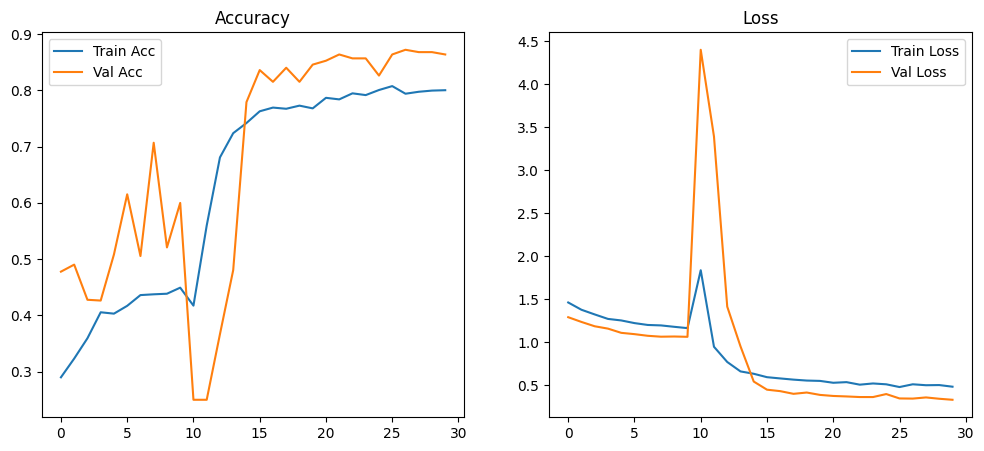

In [14]:




# Step 11: Plot curves
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'] + history2.history['accuracy'], label='Train Acc')
plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history1.history['loss'] + history2.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'] + history2.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

plt.show()